In [ ]:
!git clone https://github.com/thissop/QPOML.git
%cd QPOML
!pip install .


fatal: destination path 'QPOML' already exists and is not an empty directory.
/content/QPOML
Processing /content/QPOML
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
!pip install -r requirements.txt

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
from qpoml.main import collection

In [ ]:
import pandas as pd

# Example data
data = {
    "mass": [8.1, 9.2],
    "accretion_rate": [0.4, 0.6],
    "spin": [0.9, 0.95],
    "frequency": [220, 300]
}

df = pd.DataFrame(data)
df.to_csv("data.csv", index=False)


In [ ]:
def first_version_fake_data(observations=100):
    import numpy as np
    import pandas as pd

    qpo_ids = []
    freqs = []
    widths = []
    norms = []

    context_observation_IDs = []
    context_rows = []
    for i in range(observations):


        id = str(i)
        if len(id)==1:
            id = 'ID_00'+id
        else:
            id = 'ID_0'+id

        context_observation_IDs.append(id)

        def random_intensity():
            return int(20*np.random.random(1)+1) #[1-20)

        context_row = [id]+[random_intensity() for k in range(5)] # twenty spectrum channels
        context_rows.append(context_row)

        for j in range(np.random.randint(1, 4)):
            qpo_ids.append(id)
            freq = 1+15*np.random.random(1)[0] # [1,16)
            freqs.append(freq)
            width = 0.1*freq # [0.1,1.6)
            widths.append(width)
            norm = 1+5*np.random.random(1)[0] #[1,6)
            norms.append(norm)

    qpo_df = pd.DataFrame()
    qpo_df['observation_ID'] = qpo_ids
    qpo_df['frequency'] = freqs
    qpo_df['width'] = widths
    qpo_df['amplitude'] = norms

    n = 5
    channel_means = np.arange(0.5, (n+1)*0.5, 0.5)
    channel_ranges = [(i-0.25, i+0.25) for i in channel_means]

    channel_means = [str(i)+'_' for i in channel_means]
    columns = [channel_means[index]+str(channel_ranges[index][0])+'-'+str(channel_ranges[index][1]) for index in range(n)]


    context_df = pd.DataFrame(context_rows, columns=['observation_ID']+columns)

    qpo_df.to_csv('fake_generated_qpos.csv', index=False)
    context_df.to_csv('fake_generated_spectrum.csv', index=False)

def fake_context_data_with_scalars():
    import pandas as pd
    import numpy as np

    fake_ids = np.array(pd.read_csv('fake_generated_spectrum.csv')['observation_ID'])

    size = len(fake_ids)

    gammas = np.random.uniform(1.1, 3.3, size=size)
    tins = np.random.uniform(0.1, 2, size=size)
    hardness = np.random.uniform(size=size)

    scalar_df = pd.DataFrame(np.array([fake_ids, gammas, tins, hardness]).T,
                             columns=['observation_ID', 'gamma', 'T_in', 'hardness'])

    scalar_df.to_csv('fake_generated_scalar_context.csv', index=False)


In [ ]:
first_version_fake_data()

/tmp/ipython-input-5-1269277039.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(20*np.random.random(1)+1) #[1-20)


In [ ]:
fake_context_data_with_scalars()

In [ ]:
from qpoml.main import *

from qpoml import utilities

from qpoml import plotting


In [ ]:
col = collection()
col_1 = collection()
col.load(qpo_csv = 'fake_generated_qpos.csv',
         context_csv = 'fake_generated_scalar_context.csv',
         context_preprocess = {'gamma': 'median', 'T_in': 'median', 'hardness': 'median'},
         approach = 'regression',
         qpo_preprocess = {'frequency': 'normalize', 'width': 'normalize', 'amplitude': 'normalize'},
         units = {'frequency': 'Hz', 'width': 'Hz', 'amplitude': 'arb. units'})


In [ ]:
col_1.load(qpo_csv = 'fake_generated_qpos.csv',
           context_csv = 'fake_generated_scalar_context.csv',
         context_preprocess = {'gamma': 'median', 'T_in': 'median', 'hardness': 'median'},
         approach = 'regression',
           qpo_preprocess = {'frequency': 'normalize', 'width': 'normalize', 'amplitude': 'normalize'},
         units = {'frequency': 'Hz', 'width': 'Hz', 'amplitude': 'arb. units'})

In [ ]:
col_1

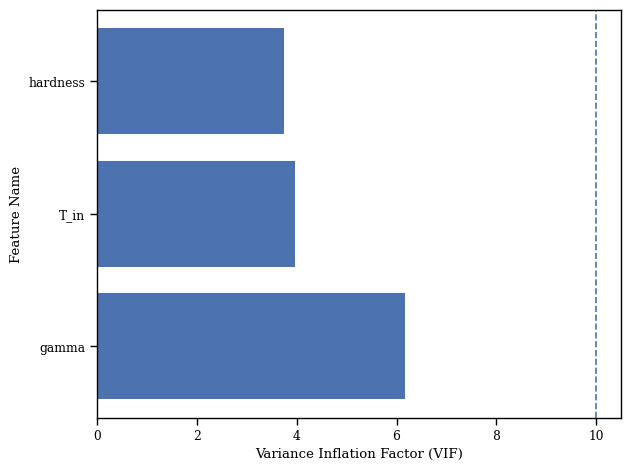

In [ ]:
col.plot_vif()

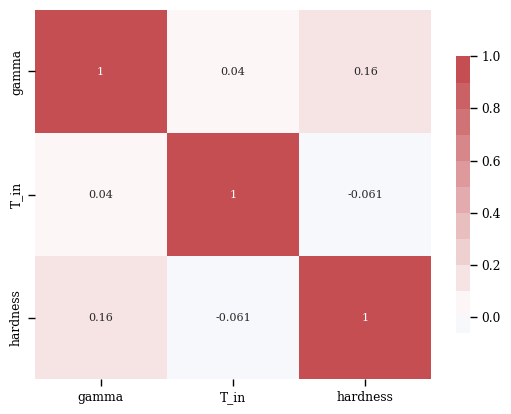

In [ ]:
col.plot_correlation_matrix()

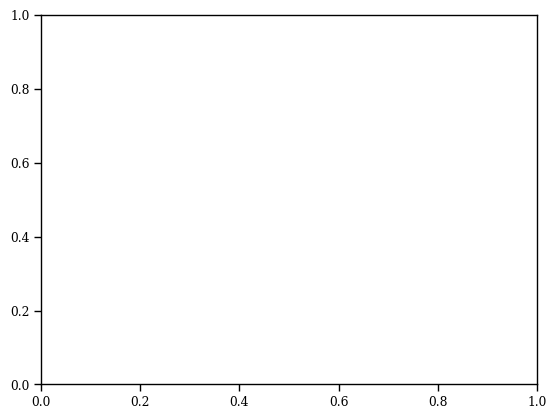

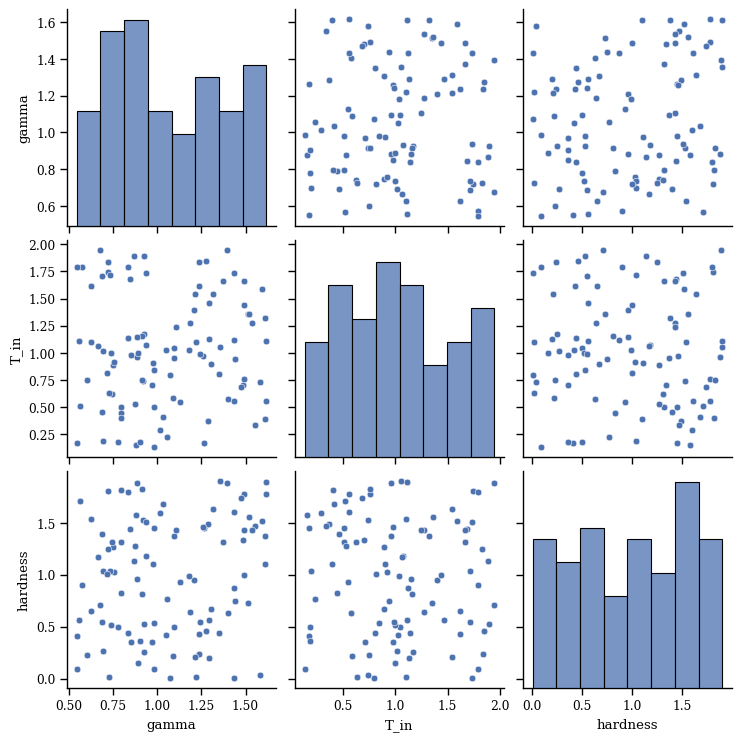

In [ ]:
col.plot_pairplot()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
gridsearch = {
    "n_estimators": [100, 200],
    "random_state": [0, 1]}
col.evaluate(model = regressor,
        evaluation_approach = 'k-fold',
        test_proportion = 0.2,
        folds = 10,
        repetitions = None,
        gridsearch_dictionary = gridsearch,
        stratify = None)
predictions = col.prediction
print(predictions)

[[0.51086233 0.51086233 0.47931724 0.2911031  0.2911031  0.20760864
  0.19777208 0.19777208 0.21918084]
 [0.65745308 0.65745308 0.2940048  0.12625696 0.12625696 0.12812215
  0.12695013 0.12695013 0.11243611]
 [0.57426344 0.57426344 0.40972942 0.23395637 0.23395637 0.14873864
  0.18879386 0.18879386 0.10492896]
 [0.4906553  0.4906553  0.60127333 0.45187104 0.45187104 0.27486014
  0.41197016 0.41197016 0.31161867]
 [0.48299156 0.48299156 0.58838185 0.35895073 0.35895073 0.28326683
  0.42033489 0.42033489 0.27702041]
 [0.46688996 0.46688996 0.45465828 0.2797813  0.2797813  0.33438281
  0.27392178 0.27392178 0.3698883 ]
 [0.53865086 0.53865086 0.53517006 0.38223194 0.38223194 0.27845144
  0.15070132 0.15070132 0.10849433]
 [0.41354585 0.41354585 0.60234288 0.4608029  0.4608029  0.34861241
  0.49176771 0.49176771 0.54633936]
 [0.49447449 0.49447449 0.51364578 0.33643324 0.33643324 0.26240218
  0.0700156  0.0700156  0.06679926]
 [0.51355692 0.51355692 0.50418391 0.36838222 0.36838222 0.31871

In [ ]:
print(col.results_regression(feature_name='frequency', which = [0]))

(array([ 6.60817607,  9.76874945,  5.53307412,  7.76866061,  3.86023201,
        2.57431057, 11.39902254,  3.52339995, 14.27244023, 10.54888341,
       12.86301644,  4.33650463,  2.69046993,  4.67711232,  6.41745203,
        5.96892691,  6.65865769,  1.66322702,  7.07637573,  1.78373427]), array([ 7.86450117, 10.29766318,  8.91685387,  7.52909831,  7.401893  ,
        7.13463327,  8.32574446,  6.24921007,  7.59249052,  7.90922693,
        8.32845898,  7.82121654,  4.53630361,  7.25168937,  4.39295699,
        6.44831963,  9.19333258,  7.06901675,  6.87532953,  6.58743893]), LinregressResult(slope=np.float64(0.1693793826356731), intercept=np.float64(6.2853670420436405), rvalue=np.float64(0.4446174785313862), pvalue=np.float64(0.0495085830275382), stderr=np.float64(0.0804285609245108), intercept_stderr=np.float64(0.5963316984599216)))


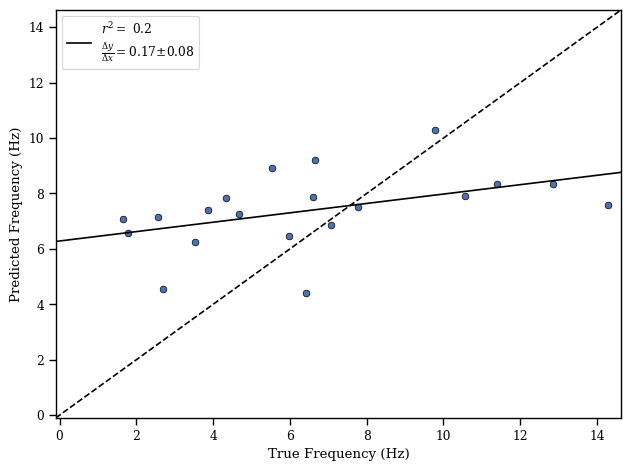

In [ ]:
col.plot_results_regression(feature_name='frequency', which = [0])

In [ ]:
col.get_performance_statistics(predicted_feature_name='frequecny')

AttributeError: 'collection' object has no attribute 'predictions'